In [13]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.image import imread

synt_path = '../../synt_one_channel'
val_path = '/mnt/jet1/zagorulia/val_one_channel'

In [14]:
print(os.listdir(f'{val_path}'))
print(os.listdir(f'{synt_path}'))

['3', '1', '2', '0']
['3', '0', '2', '1']


In [15]:
def getIntensities(morph_cls):
    synt_intensities = []
    val_intensities = []
    for file in os.listdir(f'{synt_path}/{morph_cls}'):
        im = imread(f'{synt_path}/{morph_cls}/{file}')
        synt_intensities.append(im.sum())

    for file in os.listdir(f'{val_path}/{morph_cls}'):
        im = imread(f'{val_path}/{morph_cls}/{file}')
        val_intensities.append(im.sum())
    return (synt_intensities, val_intensities)

In [16]:
def plotIntensities(synt_intensities, val_intensities):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].hist(np.array(synt_intensities).ravel(), bins=100)
    axes[0].axvline(np.array(synt_intensities).mean(), ls='--', color='black', label='mean')
    axes[0].axvline(np.median(np.array(synt_intensities)), ls='--', color='red', label='median')
    axes[0].set_title('Интегральная яркость (обучение)')
    axes[0].set_yscale('log')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].hist(np.array(val_intensities).ravel(), bins=100)
    axes[1].axvline(np.array(val_intensities).mean(), ls='--', color='black', label='mean')
    axes[1].axvline(np.median(np.array(val_intensities)), ls='--', color='red', label='median')
    axes[1].set_title('Интегральная яркость (валидация)')
    # axes[1].set_yscale('log')
    axes[1].grid(True)
    axes[1].legend()

## Single Point Source

1830.9277 419.27856
8000 242


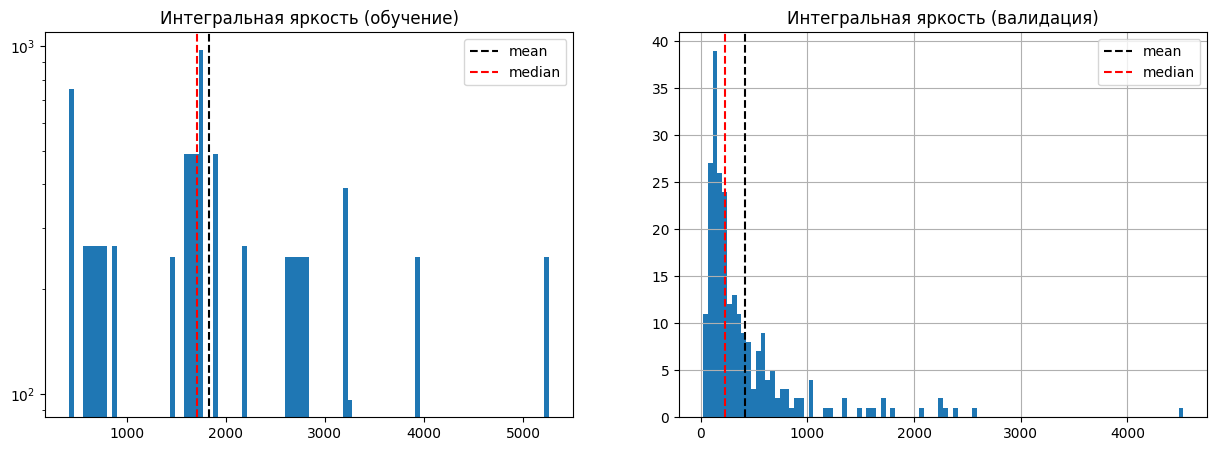

In [17]:
intensities = getIntensities(0)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)

## Double Point Source

2037.954 400.10684
8000 69


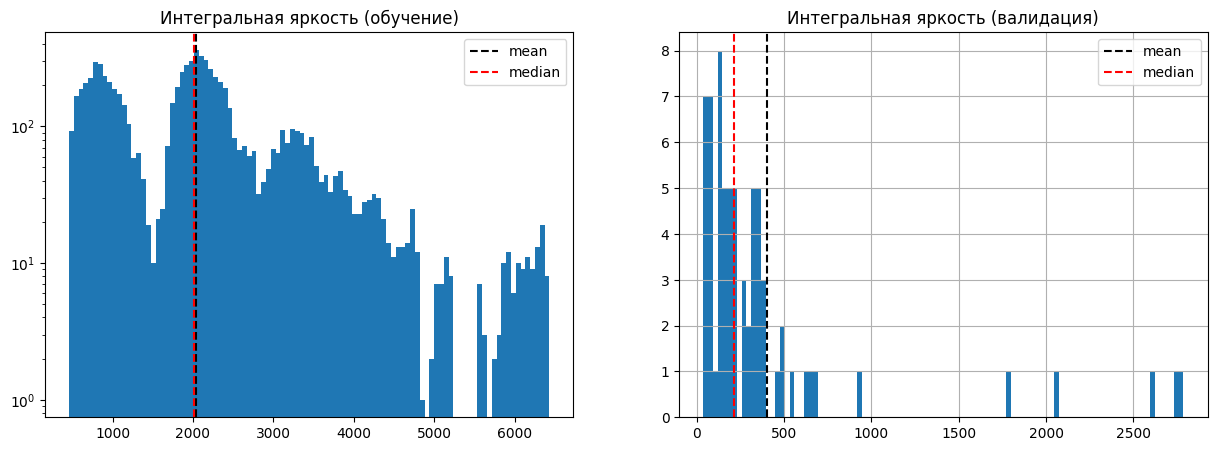

In [18]:
intensities = getIntensities(1)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)

## Single Jet Sources

1822.4332 386.84912
8000 250


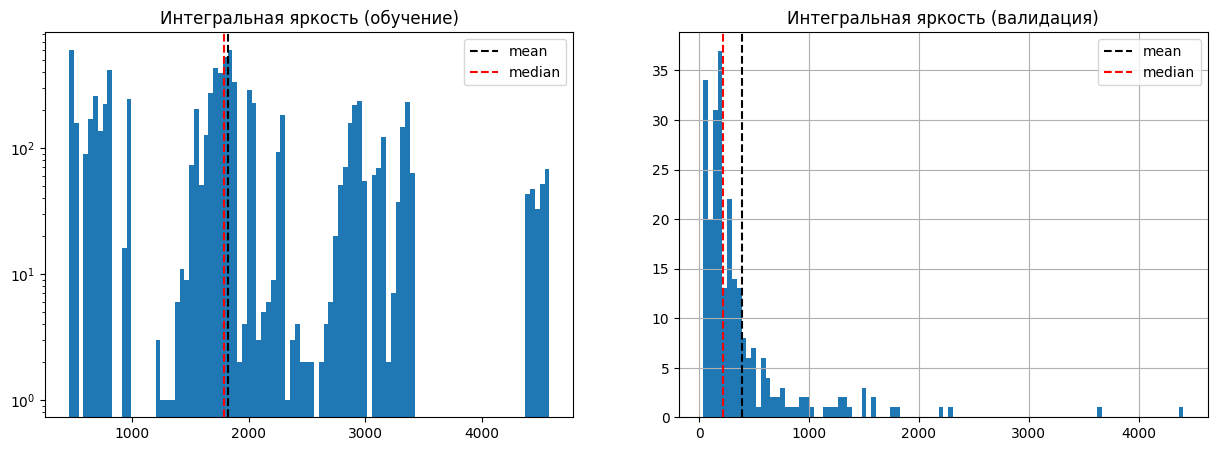

In [19]:
intensities = getIntensities(2)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)

## Double Jet Sources

1773.7977 427.35464
8000 26


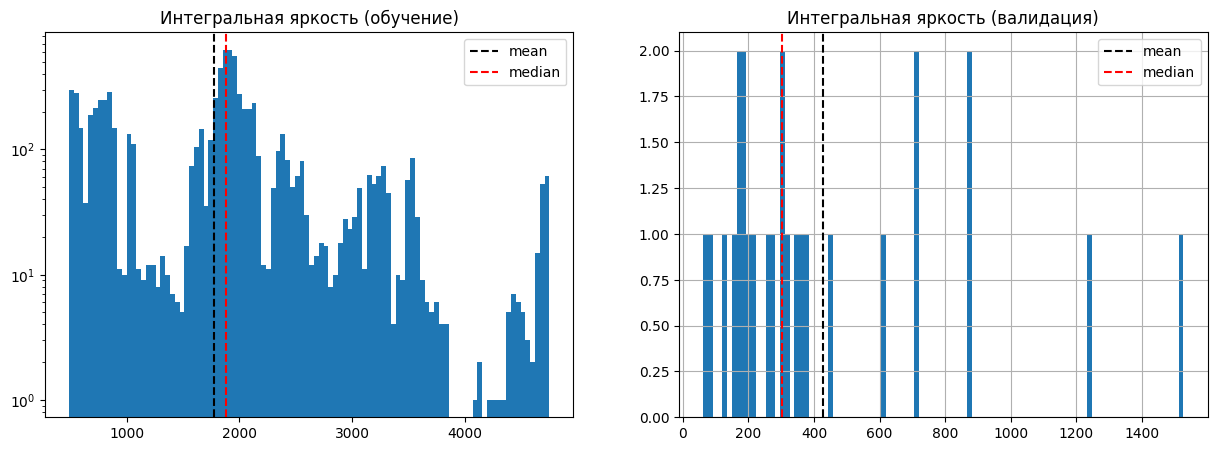

In [20]:
intensities = getIntensities(3)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)